In [2]:
# ── CELL 1: Install & imports ─────────────────────────────────────────────────
# !pip install scikit-learn --quiet  # already available on Kaggle

import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    brier_score_loss, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
# ── CELL 2: Load data ─────────────────────────────────────────────────────────
# Adjust DATA_DIR to wherever you uploaded the dataset on Kaggle
DATA_DIR = Path("/kaggle/input/datasets/test12345sdasd/email-triage-model-ready")  # <-- update if needed

def load_jsonl(path):
    with open(path) as f:
        return pd.DataFrame([json.loads(l) for l in f if l.strip()])

train = load_jsonl(DATA_DIR / "train.jsonl")
val   = load_jsonl(DATA_DIR / "val.jsonl")
test  = load_jsonl(DATA_DIR / "test.jsonl")

print(f"Train: {len(train)}  Val: {len(val)}  Test: {len(test)}")
print("Label distribution (train):", train.label.value_counts().to_dict())


Train: 15483  Val: 3188  Test: 3189
Label distribution (train): {'phishing': 8574, 'spam': 6909}


In [4]:

# ── CELL 3: Feature preparation ───────────────────────────────────────────────
# Label encoding: spam=0, phishing=1
LABEL_MAP = {"spam": 0, "phishing": 1}

# Zero-variance columns — carry no information in this dataset
DROP_COLS = ["executable_detected", "macro_detected"]

STRUCTURED_COLS = [
    "display_from_mismatch", "reply_to_mismatch", "free_email_sender",
    "url_count", "domain_count", "shortened_url_present", "suspicious_tld_present",
    "ip_literal_url", "url_entropy", "typosquatting_detected",
    "has_attachment",
    "subject_length", "body_length", "uppercase_ratio", "digit_ratio",
    "punctuation_density", "link_density",
    "brand_mention", "sender_brand_mismatch",
]

def get_text(df):
    """Combine subject + body into a single string for TF-IDF."""
    subj = df["subject"].fillna("").astype(str)
    body = df["body_text"].fillna("").astype(str)
    return (subj + " [SEP] " + body).tolist()

def get_structured(df):
    return df[STRUCTURED_COLS].astype(float).values

y_train = train["label"].map(LABEL_MAP).values
y_val   = val["label"].map(LABEL_MAP).values
y_test  = test["label"].map(LABEL_MAP).values

# TF-IDF on text
tfidf = TfidfVectorizer(
    max_features=50_000,
    sublinear_tf=True,
    ngram_range=(1, 2),
    min_df=2,
    strip_accents="unicode",
)
X_text_train = tfidf.fit_transform(get_text(train))
X_text_val   = tfidf.transform(get_text(val))
X_text_test  = tfidf.transform(get_text(test))

# Scale structured features (LR requires scaling)
scaler = StandardScaler()
X_struct_train = scaler.fit_transform(get_structured(train))
X_struct_val   = scaler.transform(get_structured(val))
X_struct_test  = scaler.transform(get_structured(test))

# Combine: sparse TF-IDF + dense structured
from scipy.sparse import hstack, csr_matrix
X_train = hstack([X_text_train, csr_matrix(X_struct_train)])
X_val   = hstack([X_text_val,   csr_matrix(X_struct_val)])
X_test  = hstack([X_text_test,  csr_matrix(X_struct_test)])

print(f"Feature matrix shape — Train: {X_train.shape}")



Feature matrix shape — Train: (15483, 50019)


In [5]:

# ── CELL 4: Train + calibrate ─────────────────────────────────────────────────
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="saga",
    class_weight=None,   # balanced dataset, no weighting needed initially
    random_state=42,
    n_jobs=-1,
)
lr.fit(X_train, y_train)

# Calibrate on validation set (Platt scaling)
calibrated = CalibratedClassifierCV(lr, method="sigmoid", cv="prefit")
calibrated.fit(X_val, y_val)

print("Training complete.")

Training complete.



  Validation Set
              precision    recall  f1-score   support

        spam     0.9182    0.9176    0.9179      1480
    phishing     0.9286    0.9292    0.9289      1708

    accuracy                         0.9238      3188
   macro avg     0.9234    0.9234    0.9234      3188
weighted avg     0.9238    0.9238    0.9238      3188

ROC-AUC:   0.9693
PR-AUC:    0.9730
Brier:     0.0610


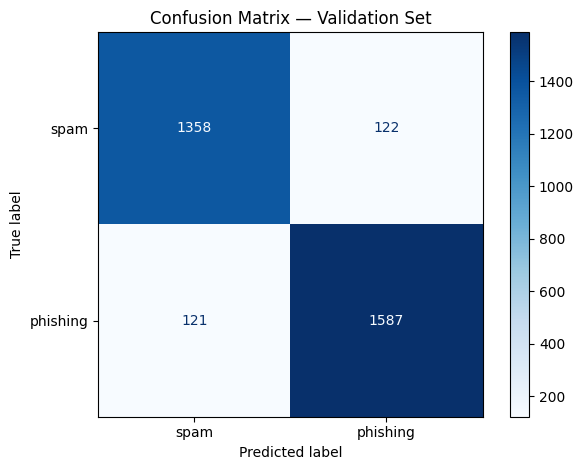


  Test Set (held-out)
              precision    recall  f1-score   support

        spam     0.9345    0.9251    0.9298      1481
    phishing     0.9356    0.9438    0.9397      1708

    accuracy                         0.9351      3189
   macro avg     0.9350    0.9344    0.9347      3189
weighted avg     0.9351    0.9351    0.9351      3189

ROC-AUC:   0.9720
PR-AUC:    0.9687
Brier:     0.0553


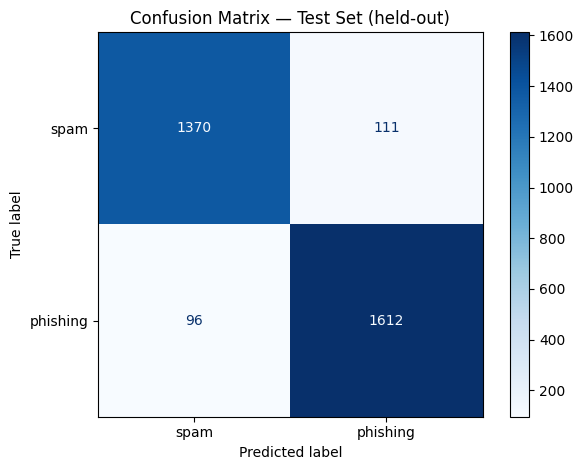

In [6]:

# ── CELL 5: Evaluate on validation set ───────────────────────────────────────
def evaluate(model, X, y_true, split_name):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]   # phishing probability

    print(f"\n{'='*50}")
    print(f"  {split_name}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=["spam", "phishing"], digits=4))

    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print(f"PR-AUC:    {average_precision_score(y_true, y_proba):.4f}")
    print(f"Brier:     {brier_score_loss(y_true, y_proba):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["spam", "phishing"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {split_name}")
    plt.tight_layout()
    plt.show()

    return y_proba

val_proba  = evaluate(calibrated, X_val,  y_val,  "Validation Set")
test_proba = evaluate(calibrated, X_test, y_test, "Test Set (held-out)")


In [7]:

# ── CELL 6: Confidence routing simulation ────────────────────────────────────
def trust_score(proba_phishing, w1=0.6, w2=0.4):
    """Compute trust score per models.md spec."""
    proba_spam = 1 - proba_phishing
    max_prob   = np.maximum(proba_phishing, proba_spam)
    margin     = np.abs(proba_phishing - proba_spam)
    return (w1 * max_prob + w2 * margin) * 100

def route(trust):
    if trust > 90:   return "auto_classify"
    if trust > 75:   return "auto_classify_monitor"
    if trust > 55:   return "analyst_review"
    return "priority_analyst_review"

test_trust  = trust_score(test_proba)
test_routes = pd.Series([route(t) for t in test_trust])

print("\n=== ROUTING DISTRIBUTION (Test Set) ===")
print(test_routes.value_counts().to_dict())

# Phishing recall within auto-classified only
auto_mask = test_trust > 75
auto_true = y_test[auto_mask]
auto_pred = (test_proba[auto_mask] >= 0.5).astype(int)
if auto_mask.sum() > 0:
    from sklearn.metrics import recall_score
    print(f"\nAuto-classified: {auto_mask.sum()} / {len(y_test)} ({auto_mask.mean()*100:.1f}%)")
    print(f"Phishing recall (auto only): {recall_score(auto_true, auto_pred):.4f}")




=== ROUTING DISTRIBUTION (Test Set) ===
{'auto_classify': 2122, 'auto_classify_monitor': 519, 'analyst_review': 334, 'priority_analyst_review': 214}

Auto-classified: 2641 / 3189 (82.8%)
Phishing recall (auto only): 0.9789


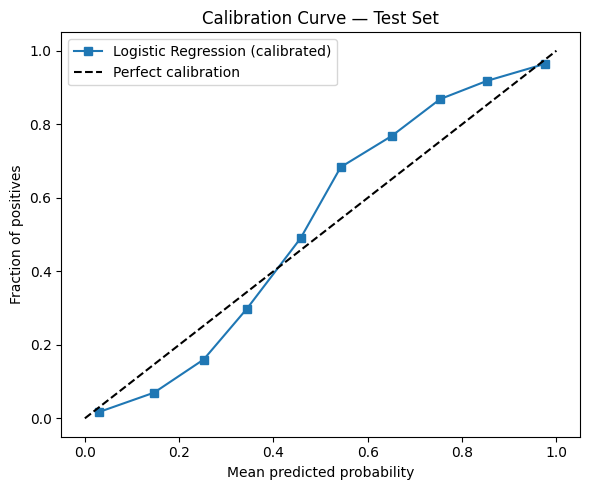


ECE: 0.4043  (target < 0.05)


In [8]:

# ── CELL 7: Calibration plot ──────────────────────────────────────────────────
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, test_proba, n_bins=10)
plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, "s-", label="Logistic Regression (calibrated)")
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve — Test Set")
plt.legend()
plt.tight_layout()
plt.show()

# Expected Calibration Error (ECE)
bin_edges = np.linspace(0, 1, 11)
ece = 0.0
for i in range(len(bin_edges) - 1):
    mask = (test_proba >= bin_edges[i]) & (test_proba < bin_edges[i+1])
    if mask.sum() == 0:
        continue
    acc  = (y_test[mask] == (test_proba[mask] >= 0.5).astype(int)).mean()
    conf = test_proba[mask].mean()
    ece += mask.mean() * abs(acc - conf)
print(f"\nECE: {ece:.4f}  (target < 0.05)")

In [9]:
feature_names = (
    tfidf.get_feature_names_out().tolist() + STRUCTURED_COLS
)
coefs = lr.coef_[0]

top_phishing = np.argsort(coefs)[-20:][::-1]
top_spam     = np.argsort(coefs)[:20]

print("\n=== TOP 20 PHISHING FEATURES ===")
for i in top_phishing:
    print(f"  {feature_names[i]:<40} {coefs[i]:+.4f}")

print("\n=== TOP 20 SPAM FEATURES ===")
for i in top_spam:
    print(f"  {feature_names[i]:<40} {coefs[i]:+.4f}")



=== TOP 20 PHISHING FEATURES ===
  account                                  +2.8572
  email                                    +2.0713
  monkey                                   +1.7512
  click                                    +1.7473
  monkey org                               +1.7180
  jose                                     +1.6617
  please                                   +1.6537
  bank                                     +1.6346
  your                                     +1.5953
  your account                             +1.5298
  click here                               +1.4947
  jose monkey                              +1.4432
  money                                    +1.3700
  transfer                                 +1.2579
  org                                      +1.1717
  security                                 +1.1704
  business                                 +1.1527
  body_length                              +1.1434
  mail                                     +1.11